# 04 · Score correlations

How do all the available scoring signals relate, and how well does each track activity? 'Theirs' are the scores shipped with the data (Boltz-2, Boltzina and its recycle1 / mask / docking variants, GNINA, Vina). 'Ours' are our Pass-1 co-folding confidence metrics and our CPU baselines (LightGBM-ECFP, nearest-active). Our Boltz-2 No-FT and head-FT scores are reserved here - they require the pipeline scoring that is still running.

Note availabilities: GNINA/Vina exist for ~22k compounds; our confidence for the ~21k folded so far; everything else for all 49,985. Correlations are Spearman, computed pairwise.

In [1]:

import gzip, os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
warnings.filterwarnings("ignore")
BLK="#000000"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); R=ROOT/"results/runs/588689"
raw=pd.read_csv(ROOT/"data/mf-pcba_test/588689.csv"); raw["CID"]=raw.CID.astype(int)
raw["Active"]=raw["target_active_v2"].astype(bool).astype(int)
ids=[int(x.strip().removeprefix("588689_")) for x in gzip.open(ROOT/"BoltzFT/data/splits/588689.txt.gz","rt")]
raw=raw.set_index("CID").loc[ids].reset_index(); raw["rank"]=np.arange(1,len(raw)+1)
# merge our Pass-1 confidence (folded subset)
qc=pd.read_csv(R/"qc.csv")[["CID","complex_plddt","ptm","iptm","ligand_iptm","complex_pde"]]
df=raw.merge(qc,on="CID",how="left")
print(f"{len(df)} compounds; confidence for {df.ligand_iptm.notna().sum()} folded; {int(df.Active.sum())} actives")


49985 compounds; confidence for 21061 folded; 486 actives


In [2]:

# our CPU baselines (compute per-compound over the full library): LightGBM-ECFP + nearest-active
import lightgbm as lgb
mfg=rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
fps=[mfg.GetFingerprint(m) if (m:=Chem.MolFromSmiles(str(s))) else None for s in df["neut-smiles"]]
bits=np.zeros((len(df),2048),dtype=np.int8)
for i,fp in enumerate(fps):
    if fp is not None: DataStructs.ConvertToNumpyArray(fp, bits[i])
tr=slice(0,300); ytr=df.Active.values[tr]
clf=lgb.LGBMClassifier(n_estimators=300,num_leaves=31,learning_rate=0.05,subsample=0.8,subsample_freq=1,
                       colsample_bytree=0.8,min_child_samples=5,min_data_in_bin=1,random_state=0,verbose=-1,n_jobs=4)
clf.fit(bits[tr],ytr)
df["LightGBM_ECFP"]=clf.predict_proba(bits)[:,1]
tafp=[fps[i] for i in range(300) if ytr[i]==1 and fps[i] is not None]
df["NearestActive"]=[max(DataStructs.BulkTanimotoSimilarity(fp,tafp)) if fp is not None else np.nan for fp in fps]
print("added LightGBM_ECFP + NearestActive over full library")


added LightGBM_ECFP + NearestActive over full library


In [3]:
SIGN={"score_boltz2":1,"score_boltzina":1,"score_boltzina_recycle1":1,"score_boltzina_mask":1,"docking_score_boltzina":-1,"docking_score_boltzina_recycle1":-1,"docking_score_boltzina_mask":-1,"score_gnina":1,"score_vina":-1,"LightGBM_ECFP":1,"NearestActive":1,"ligand_iptm":1,"iptm":1,"ptm":1,"complex_plddt":1,"complex_pde":-1}

## Spearman correlation among all scoring signals
Blue = positive rank-correlation, red = negative. Docking scores are negative-is-better, so they anti-correlate with the probability-style scores (expected).

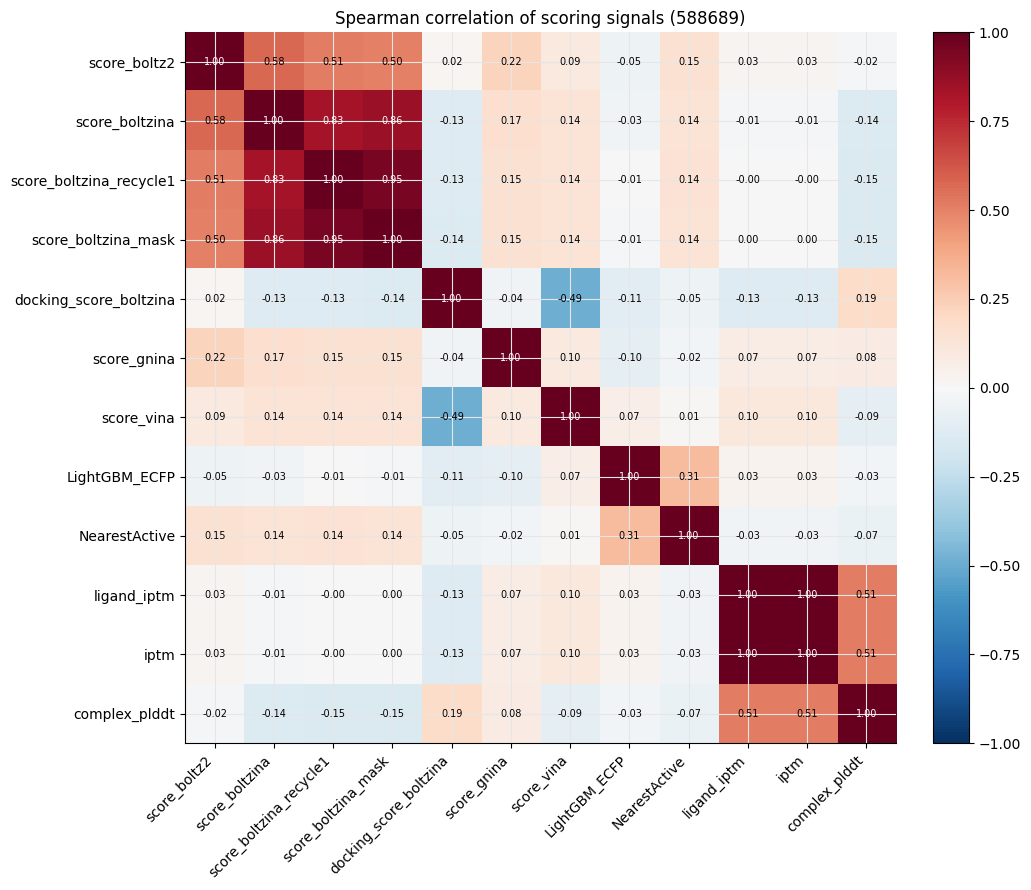

In [4]:
cols=["score_boltz2","score_boltzina","score_boltzina_recycle1","score_boltzina_mask",
      "docking_score_boltzina","score_gnina","score_vina",
      "LightGBM_ECFP","NearestActive","ligand_iptm","iptm","complex_plddt"]
cols=[c for c in cols if c in df and df[c].notna().sum()>200]
C=df[cols].corr(method="spearman")
fig,ax=plt.subplots(figsize=(11,9))
im=ax.imshow(C.values,cmap="RdBu_r",vmin=-1,vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,rotation=45,ha="right")
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        v=C.values[i,j]
        ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=7,color=("white" if abs(v)>0.6 else BLK))
fig.colorbar(im,fraction=0.046,pad=0.04); ax.set_title("Spearman correlation of scoring signals (588689)")
plt.tight_layout(); plt.show()

## Our vs theirs: how much does our nearest signal agree with their Boltz-2?
Direct pairwise Spearman of the two we care about, plus a hexbin.

  score_boltz2             vs score_boltzina    rho=+0.575  (n=49985)
  score_boltz2             vs LightGBM_ECFP     rho=-0.052  (n=49985)
  score_boltz2             vs NearestActive     rho=+0.155  (n=49985)
  score_boltz2             vs ligand_iptm       rho=+0.028  (n=21061)
  score_boltzina           vs score_gnina       rho=+0.169  (n=22126)


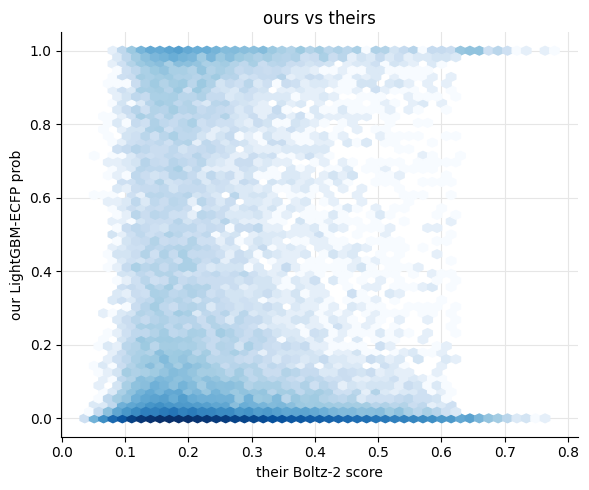

In [5]:
from scipy.stats import spearmanr
for a,b in [("score_boltz2","score_boltzina"),("score_boltz2","LightGBM_ECFP"),
            ("score_boltz2","NearestActive"),("score_boltz2","ligand_iptm"),
            ("score_boltzina","score_gnina")]:
    d=df[[a,b]].dropna()
    print(f"  {a:24s} vs {b:16s}  rho={spearmanr(d[a],d[b]).correlation:+.3f}  (n={len(d)})")
fig,ax=plt.subplots(figsize=(6,5))
d=df[["score_boltz2","LightGBM_ECFP"]].dropna()
ax.hexbin(d.score_boltz2,d.LightGBM_ECFP,gridsize=50,cmap="Blues",bins="log")
ax.set_xlabel("their Boltz-2 score"); ax.set_ylabel("our LightGBM-ECFP prob"); ax.set_title("ours vs theirs")
plt.tight_layout(); plt.show()

## Which signal tracks activity best? (AUROC)
Each signal as an activity ranker, sign-corrected (docking = lower-is-better).

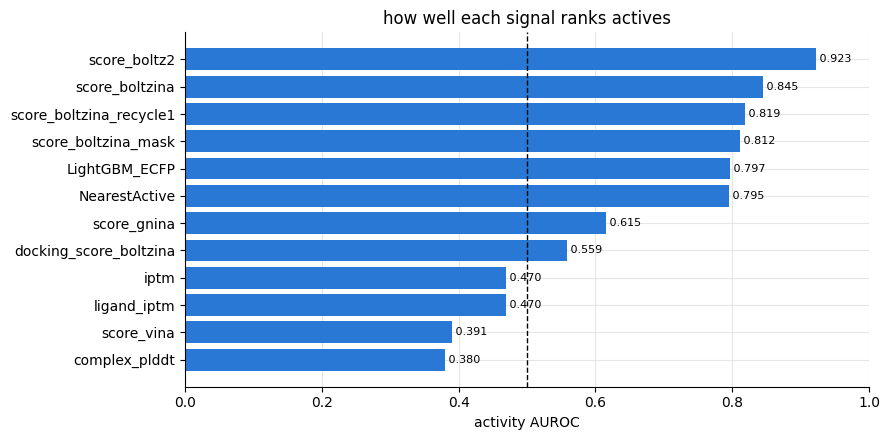

,signal,AUROC
0,score_boltz2,0.923
1,score_boltzina,0.845
2,score_boltzina_recycle1,0.819
3,score_boltzina_mask,0.812
7,LightGBM_ECFP,0.797
8,NearestActive,0.795
5,score_gnina,0.615
4,docking_score_boltzina,0.559
10,iptm,0.470
9,ligand_iptm,0.470


In [6]:
from sklearn.metrics import roc_auc_score
rows=[]
for c in cols:
    d=df[[c,"Active"]].dropna()
    if len(set(d.Active))<2 or len(d)<200: continue
    rows.append((c, roc_auc_score(d.Active, SIGN.get(c,1)*d[c].values)))
res=pd.DataFrame(rows,columns=["signal","AUROC"]).sort_values("AUROC",ascending=False)
fig,ax=plt.subplots(figsize=(9,4.5))
ax.barh(range(len(res)),res.AUROC,color="#2a78d6"); ax.axvline(0.5,color=BLK,ls="--",lw=1)
ax.set_yticks(range(len(res))); ax.set_yticklabels(res.signal); ax.invert_yaxis()
ax.set_xlim(0,1); ax.set_xlabel("activity AUROC"); ax.set_title("how well each signal ranks actives")
for i,v in enumerate(res.AUROC): ax.text(v,i,f" {v:.3f}",va="center",fontsize=8)
plt.tight_layout(); plt.show()
res.round(3)

## Pairwise scatterplots (actives highlighted)
Grey = all compounds (log density); red = confirmed actives. 'their Boltz' = shipped `score_boltz2` (their initial ranking; our No-FT rescore is reserved below). Even where two methods barely correlate overall, watch whether the red actives still land in the same (high, high) corner - agreement on the actives matters more than global correlation.

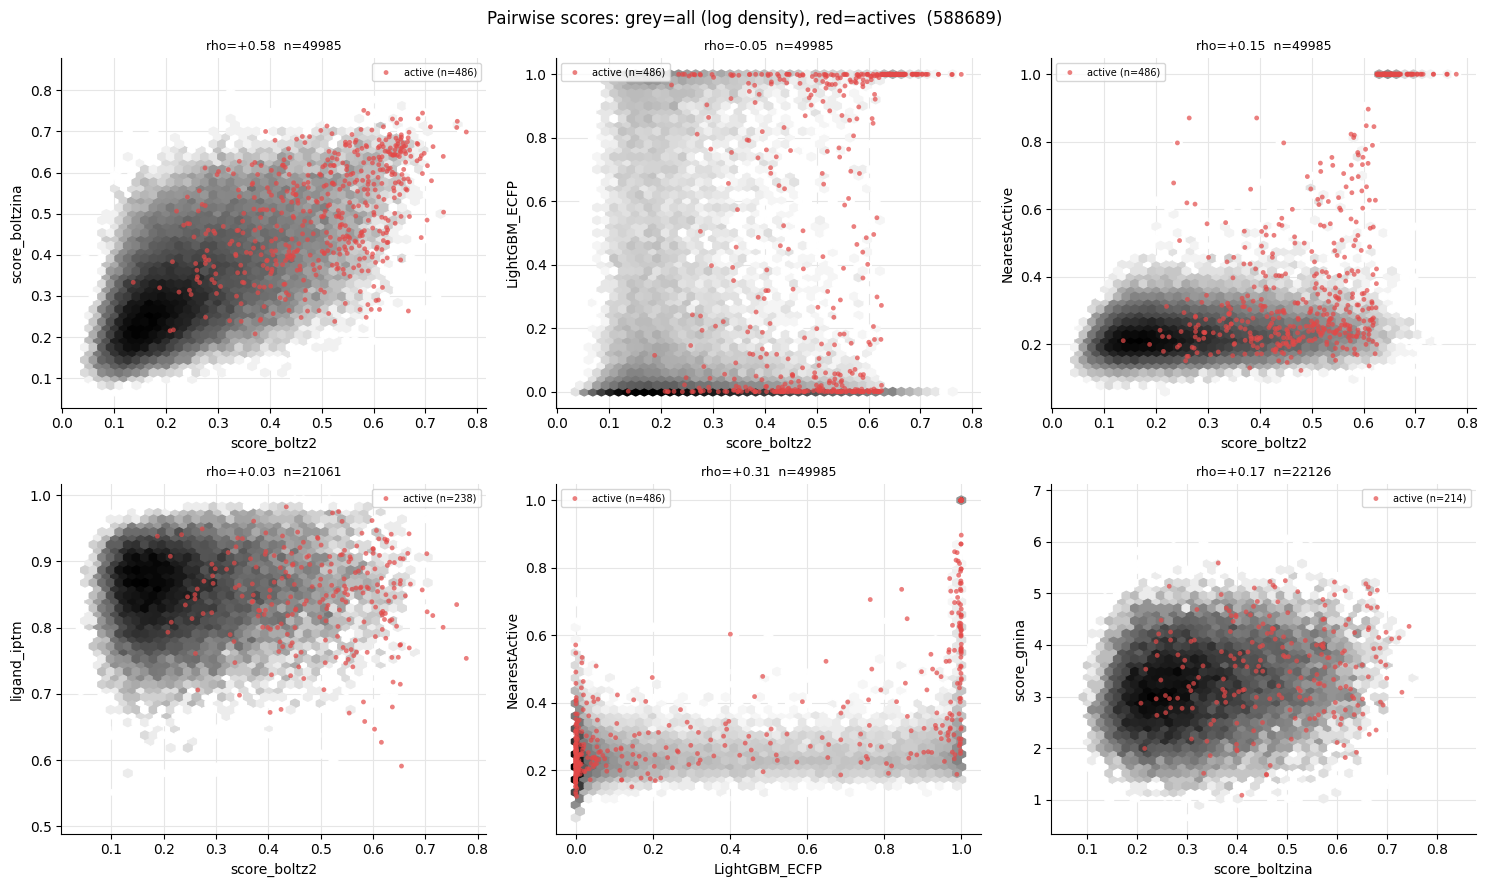

In [7]:
from scipy.stats import spearmanr
pairs=[("score_boltz2","score_boltzina"),("score_boltz2","LightGBM_ECFP"),
       ("score_boltz2","NearestActive"),("score_boltz2","ligand_iptm"),
       ("LightGBM_ECFP","NearestActive"),("score_boltzina","score_gnina")]
fig,axes=plt.subplots(2,3,figsize=(15,9))
for ax,(a,b) in zip(axes.ravel(),pairs):
    d=df[[a,b,"Active"]].dropna()
    if len(d)<200: ax.set_visible(False); continue
    ax.hexbin(d[a],d[b],gridsize=45,cmap="Greys",bins="log",mincnt=1)
    act=d[d.Active==1]
    ax.scatter(act[a],act[b],s=12,color="#e34948",alpha=.7,edgecolor="none",label=f"active (n={len(act)})")
    ax.set_xlabel(a); ax.set_ylabel(b)
    ax.set_title(f"rho={spearmanr(d[a],d[b]).correlation:+.2f}  n={len(d)}",fontsize=9)
    ax.legend(fontsize=7,loc="best")
fig.suptitle("Pairwise scores: grey=all (log density), red=actives  (588689)",fontsize=12)
plt.tight_layout(); plt.show()

## CPU methods vs activity potency
Do our fingerprint signals track the continuous single-dose potency (SD Z-score), not just the binary label? Among actives only.

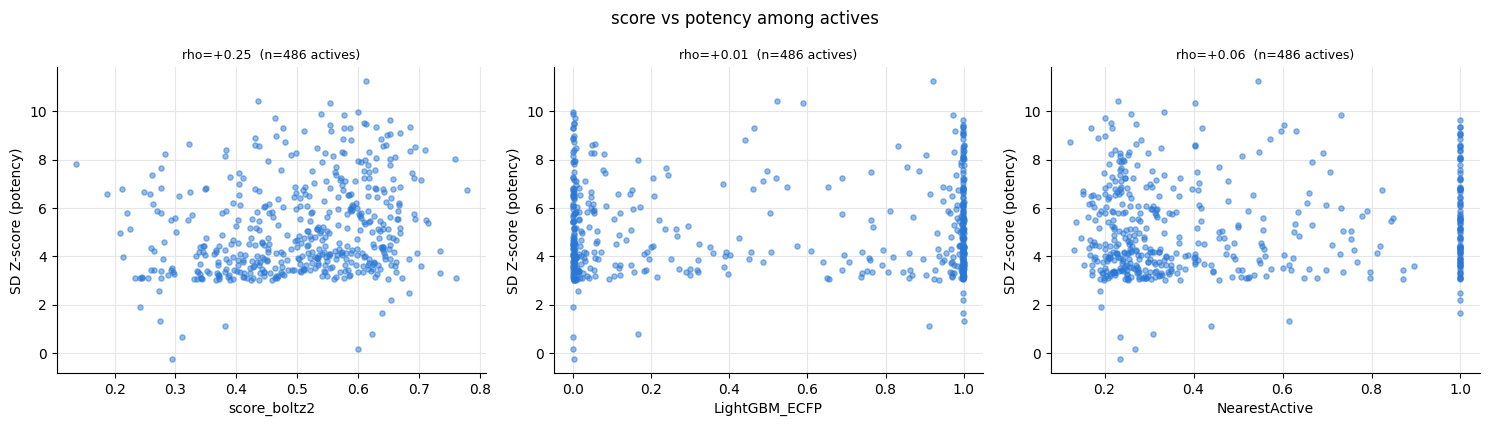

In [8]:
act=df[df.Active==1]
fig,axes=plt.subplots(1,3,figsize=(15,4.3))
for ax,c in zip(axes,["score_boltz2","LightGBM_ECFP","NearestActive"]):
    d=act[[c,"SD Z-score"]].dropna()
    ax.scatter(d[c],d["SD Z-score"],s=14,color="#2a78d6",alpha=.5)
    ax.set_xlabel(c); ax.set_ylabel("SD Z-score (potency)")
    ax.set_title(f"rho={spearmanr(d[c],d['SD Z-score']).correlation:+.2f}  (n={len(d)} actives)",fontsize=9)
fig.suptitle("score vs potency among actives",fontsize=12); plt.tight_layout(); plt.show()

## Reserved: our Boltz-2 No-FT and head-FT
Once the pipeline scoring finishes, these get merged on CID and added to the correlation matrix and the AUROC bar - the key comparison being our No-FT vs their shipped `score_boltz2` (the paper distinguishes the initial ranking from the No-FT rescore), and head-FT vs everything.